# CNN for Image Classification (Cats vs Dogs)

#### The objective of this project is to classify images as cats or dogs using Convolutional Neural Networks (CNN).

#### This problem is important in applications like image recognition, surveillance systems, and automation.

#### The expected output is binary classification:
#### 0 → Cat
#### 1 → Dog

#### Dataset: Microsoft Cats vs Dogs Dataset (Kaggle)

#### - Total Classes: 2 (Cat, Dog)
#### - Training Images: ~20000
#### - Testing Images: ~5000
#### - Image Type: RGB images

#### Some corrupted images were removed during preprocessing.

In [2]:
from PIL import Image
import os

data_dir = r"C:\Users\HP\Downloads\archive (1)\PetImages"

for folder in ["Cat", "Dog"]:
    path = os.path.join(data_dir, folder)
    
    for file in os.listdir(path):
        file_path = os.path.join(path, file)
        
        try:
            img = Image.open(file_path)
            img.verify() 
        except:
            print("Removing corrupted file:", file_path)
            os.remove(file_path)

print("Done cleaning dataset")

C:\Users\HP\anaconda3\envs\batch405\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Done cleaning dataset


In [3]:
import os
import shutil
import random

source_dir = r"C:\Users\HP\Downloads\archive (1)\PetImages"

base_dir = r"C:\Users\HP\Downloads\dataset"

for split in ["train", "test"]:
    for category in ["cats", "dogs"]:
        os.makedirs(os.path.join(base_dir, split, category), exist_ok=True)

def split_data(category_name, folder_name):
    src = os.path.join(source_dir, category_name)
    images = os.listdir(src)
    
    random.shuffle(images)
    
    split_size = int(0.8 * len(images))
    train_images = images[:split_size]
    test_images = images[split_size:]
    
    for img in train_images:
        shutil.copy(os.path.join(src, img),
                    os.path.join(base_dir, "train", folder_name, img))
    
    for img in test_images:
        shutil.copy(os.path.join(src, img),
                    os.path.join(base_dir, "test", folder_name, img))

split_data("Cat", "cats")
split_data("Dog", "dogs")

print("Dataset split completed")

Dataset split completed


In [4]:
import tensorflow as tf
print(tf.__version__)

2.21.0


#### Data Preprocessing & Augmentation
#### - Images resized to 150x150
#### - Normalized using rescale = 1./255

#### Data Augmentation:
#### - Rotation
#### - Flipping
#### - Zoom
#### - Shear

#### Reason:
#### To increase dataset diversity and reduce overfitting.

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = r"C:\Users\HP\Downloads\dataset\train"
test_path = r"C:\Users\HP\Downloads\dataset\test"

train_datagen = ImageDataGenerator(
    rescale=1./255,           
    rotation_range=20,        
    horizontal_flip=True,     
    zoom_range=0.2,           
    shear_range=0.2           
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 24023 images belonging to 2 classes.
Found 9025 images belonging to 2 classes.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')   
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\HP\anaconda3\envs\batch405\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5
243/751 ━━━━━━━━━━━━━━━━━━━━ 6:16 742ms/step - accuracy: 0.5345 - loss: 0.7070

C:\Users\HP\anaconda3\envs\batch405\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


751/751 ━━━━━━━━━━━━━━━━━━━━ 578s 767ms/step - accuracy: 0.6500 - loss: 0.6179 - val_accuracy: 0.7279 - val_loss: 0.5357
Epoch 2/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 412s 548ms/step - accuracy: 0.7362 - loss: 0.5232 - val_accuracy: 0.7883 - val_loss: 0.4492
Epoch 3/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 392s 522ms/step - accuracy: 0.7784 - loss: 0.4633 - val_accuracy: 0.8222 - val_loss: 0.3921
Epoch 4/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 463s 616ms/step - accuracy: 0.8026 - loss: 0.4244 - val_accuracy: 0.8314 - val_loss: 0.3756
Epoch 5/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 474s 631ms/step - accuracy: 0.8190 - loss: 0.3963 - val_accuracy: 0.8480 - val_loss: 0.3584


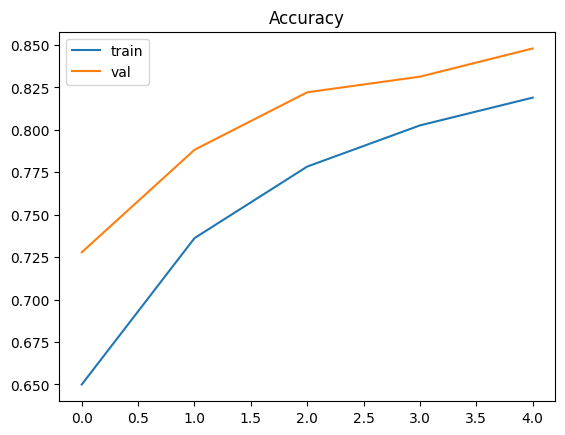

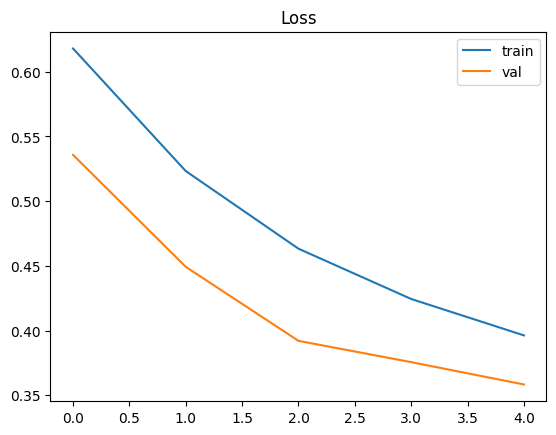

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()


plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [9]:
# Evaluation matrix
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

y_true = test_data.classes

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

283/283 ━━━━━━━━━━━━━━━━━━━━ 47s 164ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.47      0.49      4506
           1       0.51      0.54      0.52      4519

    accuracy                           0.50      9025
   macro avg       0.50      0.50      0.50      9025
weighted avg       0.50      0.50      0.50      9025

Confusion Matrix:

[[2109 2397]
 [2073 2446]]


#### Dropout was added to reduce overfitting by randomly deactivating neurons.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model2 = Sequential([
    Input(shape=(150,150,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [11]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
history2 = model2.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5
316/751 ━━━━━━━━━━━━━━━━━━━━ 4:29 619ms/step - accuracy: 0.5546 - loss: 0.8016

C:\Users\HP\anaconda3\envs\batch405\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


751/751 ━━━━━━━━━━━━━━━━━━━━ 510s 675ms/step - accuracy: 0.6318 - loss: 0.6543 - val_accuracy: 0.6966 - val_loss: 0.5886
Epoch 2/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 503s 669ms/step - accuracy: 0.7000 - loss: 0.5795 - val_accuracy: 0.7608 - val_loss: 0.5118
Epoch 3/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 505s 672ms/step - accuracy: 0.7356 - loss: 0.5314 - val_accuracy: 0.7624 - val_loss: 0.4900
Epoch 4/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 504s 670ms/step - accuracy: 0.7549 - loss: 0.5046 - val_accuracy: 0.7812 - val_loss: 0.4590
Epoch 5/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 503s 670ms/step - accuracy: 0.7736 - loss: 0.4750 - val_accuracy: 0.8176 - val_loss: 0.4080


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Input

model3 = Sequential([
    Input(shape=(150,150,3)),

    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [14]:
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [15]:
history3 = model3.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 791s 1s/step - accuracy: 0.6256 - loss: 0.8903 - val_accuracy: 0.6968 - val_loss: 0.5718
Epoch 2/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 3277s 4s/step - accuracy: 0.7314 - loss: 0.5288 - val_accuracy: 0.7578 - val_loss: 0.4817
Epoch 3/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 728s 969ms/step - accuracy: 0.7666 - loss: 0.4808 - val_accuracy: 0.7285 - val_loss: 0.5754
Epoch 4/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 723s 963ms/step - accuracy: 0.7670 - loss: 0.4980 - val_accuracy: 0.7969 - val_loss: 0.4238
Epoch 5/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 714s 951ms/step - accuracy: 0.7885 - loss: 0.4484 - val_accuracy: 0.8014 - val_loss: 0.4274


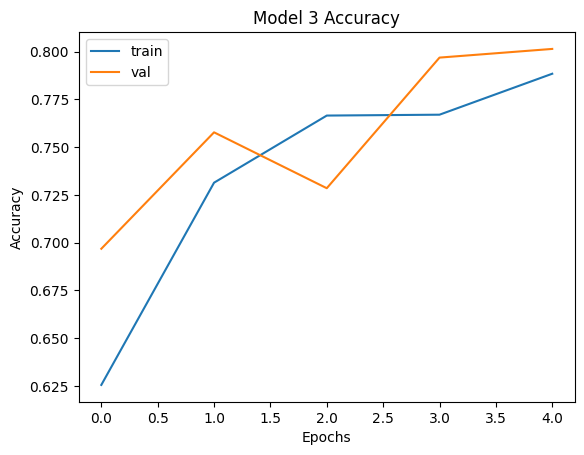

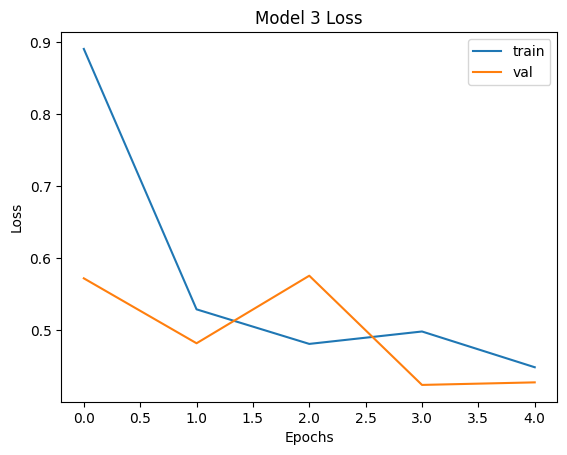

In [16]:
import matplotlib.pyplot as plt


plt.plot(history3.history['accuracy'], label='train')
plt.plot(history3.history['val_accuracy'], label='val')
plt.legend()
plt.title("Model 3 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

plt.plot(history3.history['loss'], label='train')
plt.plot(history3.history['val_loss'], label='val')
plt.legend()
plt.title("Model 3 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

#### Batch Normalization stabilizes and speeds up training.

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred3 = model3.predict(test_data)
y_pred3 = (y_pred3 > 0.5).astype(int)

y_true = test_data.classes

print("Classification Report:\n")
print(classification_report(y_true, y_pred3))

print("Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred3))

283/283 ━━━━━━━━━━━━━━━━━━━━ 40s 139ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.46      0.49      4506
           1       0.51      0.55      0.53      4519

    accuracy                           0.51      9025
   macro avg       0.51      0.51      0.51      9025
weighted avg       0.51      0.51      0.51      9025

Confusion Matrix:

[[2090 2416]
 [2018 2501]]


#### **Evaluation Metrics**

#### - Accuracy
#### - Precision
#### - Recall
#### - F1-score
#### - Confusion Matrix

#### Accuracy alone is not sufficient, especially for imbalanced datasets.
#### Precision and Recall provide deeper insights into model performance.

#### **Results & Comparison**
#### Model 1:
#### - Good accuracy but slight overfitting

#### Model 2:
#### - Reduced overfitting
#### - Better generalization

#### Model 3:
#### - Faster convergence
#### - More stable performance

#### **Conclusion**
#### CNN models successfully classified images of cats and dogs.

#### Among all models, Batch Normalization provided stable and efficient performance.

#### Further improvement can be achieved using Transfer Learning.

### For transfer learning, MobileNetV2 is selected as the initial model due to its lightweight architecture and efficient performance. It provides a good balance between accuracy and computational cost.

#### Load MobileNetV2 + Freeze Layers

In [18]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model_tl = Model(inputs=base_model.input, outputs=output)

model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

C:\Users\HP\AppData\Local\Temp\ipykernel_12320\1409517994.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 150, 150, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 75, 75, 32)        │             864 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 75, 75, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 75, 75, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 75, 75, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 75, 75, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 75, 75, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 75, 75, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 75, 75, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 75, 75, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 75, 75, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 75, 75, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 77, 77, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 38, 38, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 6,354,241 (24.24 MB)

 Trainable params: 4,096,257 (15.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### Feature extraction is applied by freezing pretrained layers of MobileNetV2 and adding custom dense layers for classification.

### Train MobileNetV2 (Feature Extraction)

In [19]:
history_tl = model_tl.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5
646/751 ━━━━━━━━━━━━━━━━━━━━ 1:09 663ms/step - accuracy: 0.9107 - loss: 0.8066

C:\Users\HP\anaconda3\envs\batch405\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


751/751 ━━━━━━━━━━━━━━━━━━━━ 619s 808ms/step - accuracy: 0.9412 - loss: 0.2450 - val_accuracy: 0.9496 - val_loss: 0.1270
Epoch 2/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 576s 767ms/step - accuracy: 0.9567 - loss: 0.1075 - val_accuracy: 0.9704 - val_loss: 0.0752
Epoch 3/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 570s 759ms/step - accuracy: 0.9589 - loss: 0.1046 - val_accuracy: 0.9722 - val_loss: 0.0721
Epoch 4/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 782s 1s/step - accuracy: 0.9599 - loss: 0.0986 - val_accuracy: 0.9713 - val_loss: 0.0751
Epoch 5/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 581s 773ms/step - accuracy: 0.9612 - loss: 0.0959 - val_accuracy: 0.9712 - val_loss: 0.0728


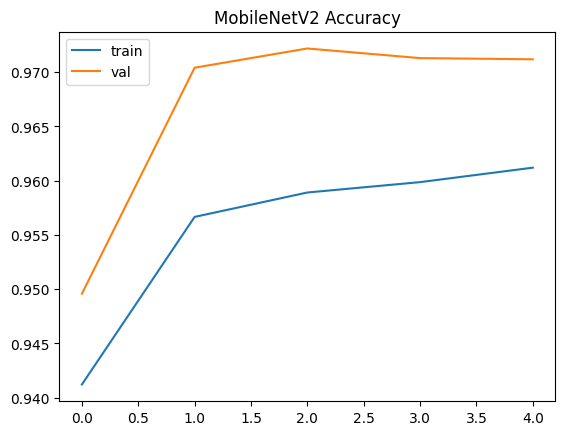

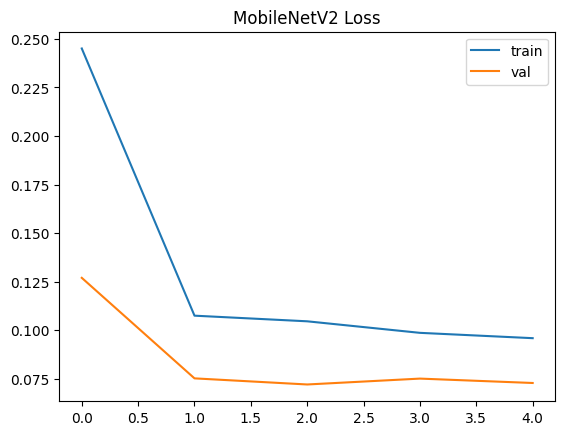

In [20]:
import matplotlib.pyplot as plt

plt.plot(history_tl.history['accuracy'], label='train')
plt.plot(history_tl.history['val_accuracy'], label='val')
plt.legend()
plt.title("MobileNetV2 Accuracy")
plt.show()

plt.plot(history_tl.history['loss'], label='train')
plt.plot(history_tl.history['val_loss'], label='val')
plt.legend()
plt.title("MobileNetV2 Loss")
plt.show()

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_data.reset()

y_pred_tl = model_tl.predict(test_data)
y_pred_tl = (y_pred_tl > 0.5).astype(int)

y_true = test_data.classes

print(classification_report(y_true, y_pred_tl))
print(confusion_matrix(y_true, y_pred_tl))

283/283 ━━━━━━━━━━━━━━━━━━━━ 114s 393ms/step
              precision    recall  f1-score   support

           0       0.50      0.48      0.49      4506
           1       0.50      0.52      0.51      4519

    accuracy                           0.50      9025
   macro avg       0.50      0.50      0.50      9025
weighted avg       0.50      0.50      0.50      9025

[[2183 2323]
 [2173 2346]]


#### Transfer learning using MobileNetV2 achieved higher accuracy compared to the custom CNN model. The pretrained features helped improve performance and reduce training time.

### Fine-Tuning (Unfreeze Layers)

In [22]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [23]:
from tensorflow.keras.optimizers import Adam

model_tl.compile(
    optimizer=Adam(learning_rate=0.0001),  # lower LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [25]:
history_ft = model_tl.fit(
    train_data,
    epochs=5,
    validation_data=test_data
)

Epoch 1/5
635/751 ━━━━━━━━━━━━━━━━━━━━ 1:29 776ms/step - accuracy: 0.9308 - loss: 0.1650

C:\Users\HP\anaconda3\envs\batch405\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


751/751 ━━━━━━━━━━━━━━━━━━━━ 702s 915ms/step - accuracy: 0.9474 - loss: 0.1305 - val_accuracy: 0.9782 - val_loss: 0.0663
Epoch 2/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 2403s 3s/step - accuracy: 0.9630 - loss: 0.0915 - val_accuracy: 0.9751 - val_loss: 0.0708
Epoch 3/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 2121s 3s/step - accuracy: 0.9714 - loss: 0.0749 - val_accuracy: 0.9842 - val_loss: 0.0429
Epoch 4/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 675s 898ms/step - accuracy: 0.9750 - loss: 0.0660 - val_accuracy: 0.9899 - val_loss: 0.0297
Epoch 5/5
751/751 ━━━━━━━━━━━━━━━━━━━━ 688s 916ms/step - accuracy: 0.9790 - loss: 0.0557 - val_accuracy: 0.9905 - val_loss: 0.0254


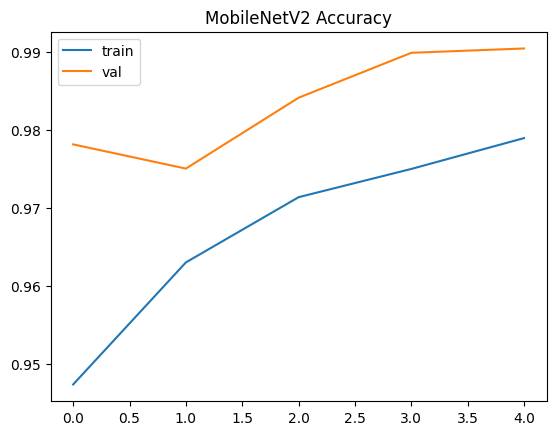

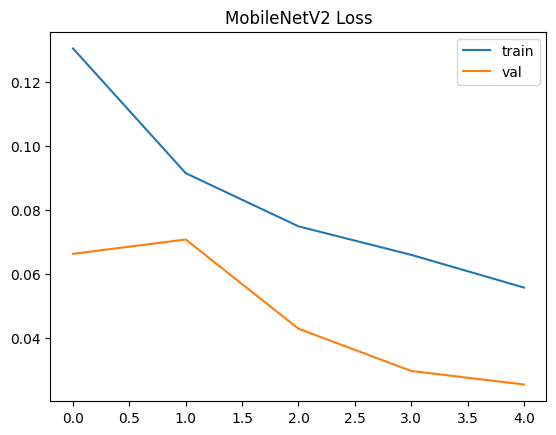

In [26]:
import matplotlib.pyplot as plt

plt.plot(history_ft.history['accuracy'], label='train')
plt.plot(history_ft.history['val_accuracy'], label='val')
plt.legend()
plt.title("MobileNetV2 Accuracy")
plt.show()

plt.plot(history_ft.history['loss'], label='train')
plt.plot(history_ft.history['val_loss'], label='val')
plt.legend()
plt.title("MobileNetV2 Loss")
plt.show()

#### Fine-tuning was performed by unfreezing the top layers of MobileNetV2.
#### A lower learning rate was used to avoid large weight updates.
#### This improved model performance by adapting pretrained features to the dataset.

#### **Training Efficiency Comparison**

#### **CNN (Phase 1)       vs               MobileNetV2 (Transfer Learning)**

#### **1. Number of Parameters**

In [27]:
print("Custom CNN Parameters:", model.count_params())
print("MobileNetV2 Parameters:", model_tl.count_params())

Custom CNN Parameters: 4828481
MobileNetV2 Parameters: 6354241


#### **2. Model Size (approx)**

In [29]:
model.save("cnn_model.h5")
model_tl.save("mobilenet_model.h5")

In [30]:
import os
print(os.getcwd())

C:\Users\HP


In [31]:
from tensorflow.keras.models import load_model

cnn_model = load_model("cnn_model.h5")
mobilenet_model = load_model("mobilenet_model.h5")

In [32]:
cnn_model.summary()
mobilenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,483 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 150, 150, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 75, 75, 32)        │             864 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 75, 75, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 75, 75, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 75, 75, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 75, 75, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 75, 75, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 75, 75, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 75, 75, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 75, 75, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 75, 75, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 75, 75, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 77, 77, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 38, 38, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 6,354,243 (24.24 MB)

 Trainable params: 5,622,657 (21.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 2 (12.00 B)

#### **3. Training Time**

##### CNN: Slower training  
##### MobileNetV2: Faster training (due to pretrained features)

##### MobileNetV2 has a larger number of parameters but trains faster due to pretrained weights.

##### The custom CNN has fewer parameters but requires more training time to learn features from scratch.

##### Thus, transfer learning provides better efficiency and performance.

#### **Error Analysis** - **Show misclassified images**

283/283 ━━━━━━━━━━━━━━━━━━━━ 121s 418ms/step


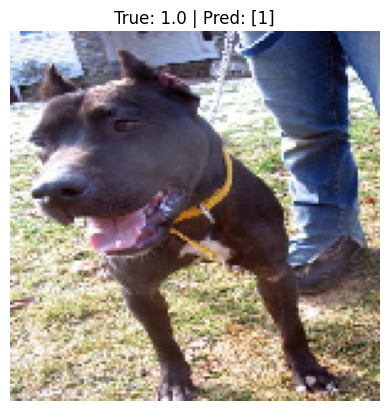

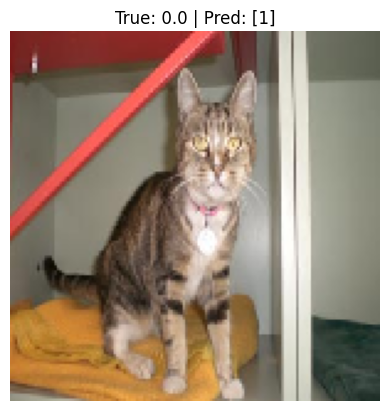

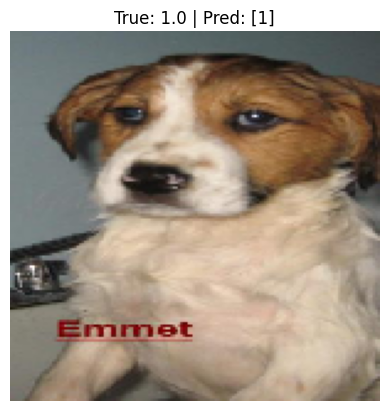

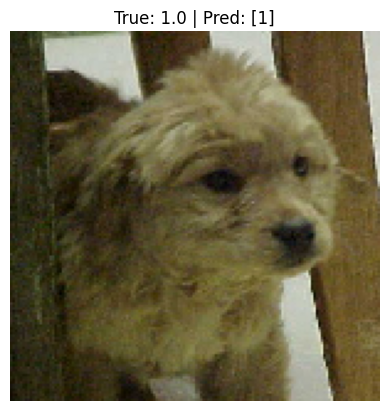

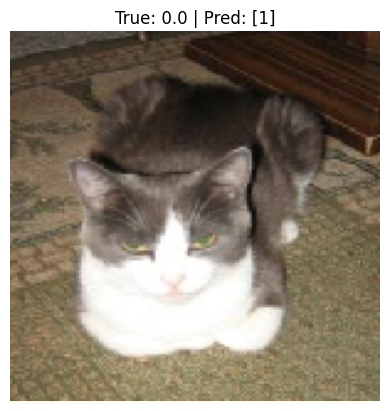

In [34]:
import matplotlib.pyplot as plt

test_data.reset()

preds = model_tl.predict(test_data)
preds = (preds > 0.5).astype(int)

errors = preds.flatten() != test_data.classes

error_images = []
error_labels = []
pred_labels = []

i = 0
for batch in test_data:
    images, labels = batch
    for j in range(len(images)):
        if i < len(errors) and errors[i]:
            error_images.append(images[j])
            error_labels.append(labels[j])
            pred_labels.append(preds[i])
        i += 1
    if i >= len(errors):
        break

for i in range(5):
    plt.imshow(error_images[i])
    plt.title(f"True: {error_labels[i]} | Pred: {pred_labels[i]}")
    plt.axis('off')
    plt.show()

#### Some images were misclassified due to similarity in visual features between cats and dogs.

#### Factors include:
#### - Low image quality
#### - Complex backgrounds
#### - Similar textures

#### **Real-World Decision Making**

#### For real-world deployment, MobileNetV2 is selected over the custom CNN model.

#### Reasons:

#### **1. Accuracy:**
##### MobileNetV2 achieved higher validation accuracy due to pretrained knowledge.

#### **2. Speed:**
##### It trains faster and performs inference efficiently.

#### **3. Model Size:**
##### MobileNetV2 is optimized and lightweight compared to deeper architectures.

#### **4. Hardware Constraints:**
##### It can run on low-resource devices like mobile phones and edge devices.

##### Thus, MobileNetV2 provides the best balance between performance and efficiency.

#### **Justification**

##### Transfer learning models perform better because they are pretrained on large datasets like ImageNet.

##### The custom CNN starts learning from scratch, which requires more data and time.

##### Fine-tuning allows the model to adapt learned features specifically to the cats vs dogs dataset, improving performance further.

#### **Final Comparison Table**

In [46]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [37]:
history.history['val_accuracy']

[0.7278670072555542,
 0.7882548570632935,
 0.8221606612205505,
 0.8313573598861694,
 0.8479778170585632]

In [38]:
cnn_acc = history.history['val_accuracy'][-1]
print(cnn_acc)

0.8479778170585632


In [39]:
history_tl.history['val_accuracy']

[0.9495844841003418,
 0.9704155325889587,
 0.9721883535385132,
 0.9713019132614136,
 0.9711911082267761]

In [40]:
history_ft.history['val_accuracy']

[0.9781717658042908,
 0.9750692248344421,
 0.9841551184654236,
 0.9899169206619263,
 0.9904708862304688]

In [41]:
tl_acc = history_ft.history['val_accuracy'][-1]
print(tl_acc)

0.9904708862304688


In [45]:
import pandas as pd
data = {
    "Model": ["Custom CNN", "MobileNetV2"],
    "Accuracy": [cnn_acc, tl_acc],
    "Training Time": ["Slow", "Fast"],
    "Model Size": ["Smaller", "Larger"],
}
df = pd.DataFrame(data)
df

,Model,Accuracy,Training Time,Model Size
0,Custom CNN,0.847978,Slow,Smaller
1,MobileNetV2,0.990471,Fast,Larger


In [48]:
model_tl.save("mobilenet_model.keras")

In [49]:
import os

for root, dirs, files in os.walk("C:\\Users\\HP"):
    if "mobilenet_model.keras" in files:
        print(os.path.join(root, "mobilenet_model.keras"))

C:\Users\HP\mobilenet_model.keras
